Brazilian E-commerce Public Dataset by Olist
===
This project analyzes the performance of an e-commerce platform using the Brazilian e-commerce public dataset. The objective is to identify key factors affecting sales, customer satisfaction, and operational efficiency, and to provide data-driven business insights.

Tools Used:

* Python
* Pandas
* Matplotlib
* Seaborn

Objective
---
The main goal is to evaluate sales performance, logistics efficiency, and customer behavior in order to uncover opportunities for business improvment.

Dataset
---
The Dataset includes information about orders, products, customers, payments and reviews. Multiple tables were combined to create a unified dataset for analysis

Data Cleaning
---
Data cleaning involved handling missing values, converting date columns into datetime format, and merging multiple tables. New features such as delivery time and delay indicators were created to support the analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv(r"C:\Users\rebec\Notebooks\data-analysis-portfolio\ecommerce-analysis-olist\tables\olist_orders_dataset.csv")
order_items = pd.read_csv(r"C:\Users\rebec\Notebooks\data-analysis-portfolio\ecommerce-analysis-olist\tables\olist_order_items_dataset.csv")
products = pd.read_csv(r"C:\Users\rebec\Notebooks\data-analysis-portfolio\ecommerce-analysis-olist\tables\olist_products_dataset.csv")
customers = pd.read_csv(r"C:\Users\rebec\Notebooks\data-analysis-portfolio\ecommerce-analysis-olist\tables\olist_customers_dataset.csv")
reviews = pd.read_csv(r"C:\Users\rebec\Notebooks\data-analysis-portfolio\ecommerce-analysis-olist\tables\olist_order_reviews_dataset.csv")

In [3]:
df = orders.merge(order_items, on="order_id").merge(products, on="product_id").merge(customers, on="customer_id").merge(reviews, on="order_id")

In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112372 non-null  object 
 1   customer_id                    112372 non-null  object 
 2   order_status                   112372 non-null  object 
 3   order_purchase_timestamp       112372 non-null  object 
 4   order_approved_at              112357 non-null  object 
 5   order_delivered_carrier_date   111188 non-null  object 
 6   order_delivered_customer_date  110012 non-null  object 
 7   order_estimated_delivery_date  112372 non-null  object 
 8   order_item_id                  112372 non-null  int64  
 9   product_id                     112372 non-null  object 
 10  seller_id                      112372 non-null  object 
 11  shipping_limit_date            112372 non-null  object 
 12  price                         

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_approved_at"] = pd.to_datetime(df["order_approved_at"])
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["shipping_limit_date"] = pd.to_datetime(df["shipping_limit_date"])
df["review_creation_date"] = pd.to_datetime(df["review_creation_date"])
df["review_answer_timestamp"] = pd.to_datetime(df["review_answer_timestamp"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112372 non-null  object        
 1   customer_id                    112372 non-null  object        
 2   order_status                   112372 non-null  object        
 3   order_purchase_timestamp       112372 non-null  datetime64[ns]
 4   order_approved_at              112357 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111188 non-null  datetime64[ns]
 6   order_delivered_customer_date  110012 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112372 non-null  datetime64[ns]
 8   order_item_id                  112372 non-null  int64         
 9   product_id                     112372 non-null  object        
 10  seller_id                      112372 non-null  object        
 11  

In [9]:
df.shape

(112372, 32)

In [10]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17,2018-02-18 13:02:51


In [11]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   15
order_delivered_carrier_date      1184
order_delivered_customer_date     2360
order_estimated_delivery_date        0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
product_category_name             1598
product_name_lenght               1598
product_description_lenght        1598
product_photos_qty                1598
product_weight_g                    18
product_length_cm                   18
product_height_cm                   18
product_width_cm                    18
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state           

Logistics, Delivery Performance and Customer Satisfaction
---

In [12]:
df["delivery_time"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

df["delay"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"])

In [13]:
df_analysis = df[df["delivery_time"].notnull()]

In [14]:
df_analysis.groupby("delay")["review_score"].mean()

delay
False    4.210476
True     2.548884
Name: review_score, dtype: float64

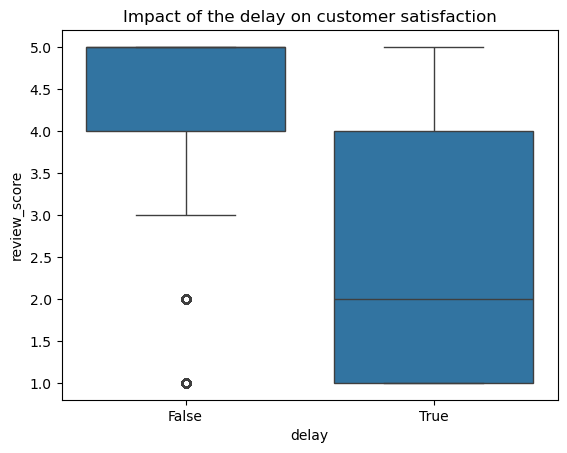

In [15]:
sns.boxplot(x="delay", y="review_score", data=df_analysis)
plt.title("Impact of the delay on customer satisfaction")
plt.show()

**Customer satisfaction**

The analysis shows that orders with delay has lower average rating compared to those delivered on time. This indicate that on-time delivery is a critical factor in customer satisfaction. 

In [16]:
df_analysis.groupby("delay")["delivery_time"].mean()

delay
False    10.386177
True     30.744189
Name: delivery_time, dtype: float64

The average days of delivery without delay is 10 days, while orders with delay has average of 30. This delivery delay could affect customer experience and the e-commerce reputation. The company could optimize logistics for orders with longer delivery time.

In [17]:
df_price = df[df["price"].notnull() & df["review_score"].notnull()]

In [18]:
df_price[["price", "review_score"]].corr()

,price,review_score
price,1.000000,-0.003941
review_score,-0.003941,1.000000


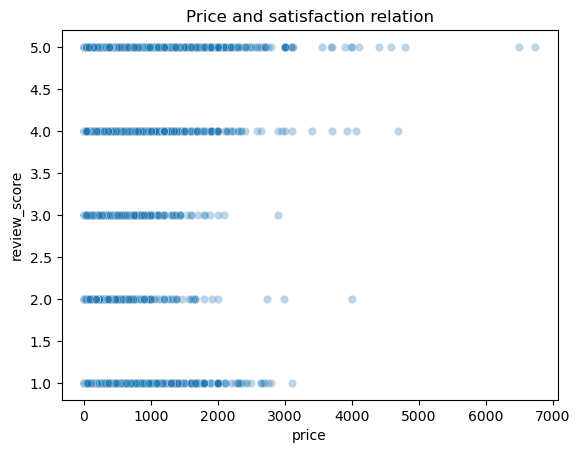

In [19]:
sns.scatterplot(x="price", y="review_score", data=df_price, alpha=0.3)
plt.title("Price and satisfaction relation")
plt.show()

In [20]:
df_price["log_price"] = np.log1p(df_price["price"])

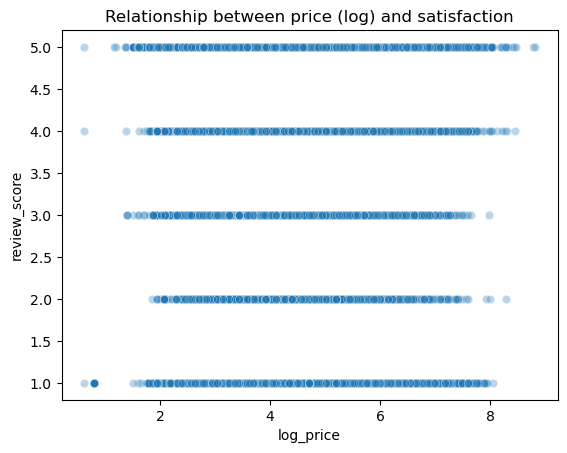

In [21]:
sns.scatterplot(x="log_price", y="review_score", data=df_price, alpha=0.3)
plt.title("Relationship between price (log) and satisfaction")
plt.show()

In [22]:
df_price["price_range"] = pd.qcut(df_price["price"], 4, labels=["cheap", "medium", "expensive", "very expensive"])

In [23]:
df_price.groupby("price_range")["review_score"].mean()

C:\Users\rebec\AppData\Local\Temp\ipykernel_3904\1715921366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price.groupby("price_range")["review_score"].mean()


price_range
cheap             4.029593
medium            4.033644
expensive         4.033620
very expensive    4.033083
Name: review_score, dtype: float64

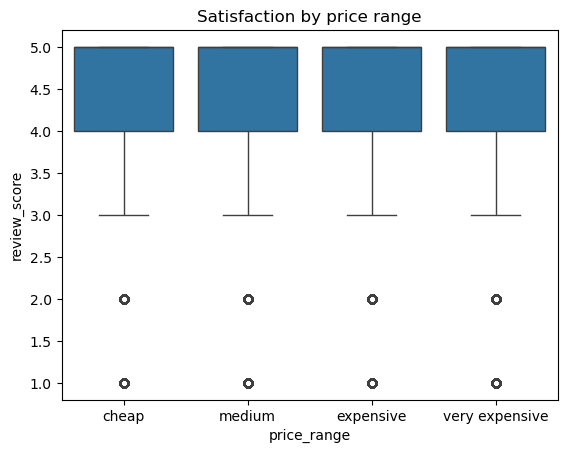

In [24]:
sns.boxplot(x="price_range", y="review_score", data=df_price)
plt.title("Satisfaction by price range")
plt.show()

The price is not shown a significant relationship between customer satisfaction, it suggests that other factors such as logistics or product quality have more influence in user experience.

In [25]:
df_price.groupby(["price_range", "delay"])["review_score"].mean().unstack()

C:\Users\rebec\AppData\Local\Temp\ipykernel_3904\2392354866.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price.groupby(["price_range", "delay"])["review_score"].mean().unstack()


delay,False,True
price_range,,
cheap,4.134813,2.605008
medium,4.150783,2.583614
expensive,4.153040,2.573039
very expensive,4.181399,2.451667


**Price does not influence customer satisfaction.**

The analysis shows that price by itself is not determine customer satisfaction. However, when it is combined with logistics factors shuch as delivery delays, the negative impact in user experience increases.

In [26]:
#Filter valid orders. Only delivered orders
df_logistics = df[df["order_delivered_customer_date"].notnull()]

In [27]:
df_logistics["delay"].value_counts(normalize=True) * 100

delay
False    92.218122
True      7.781878
Name: proportion, dtype: float64

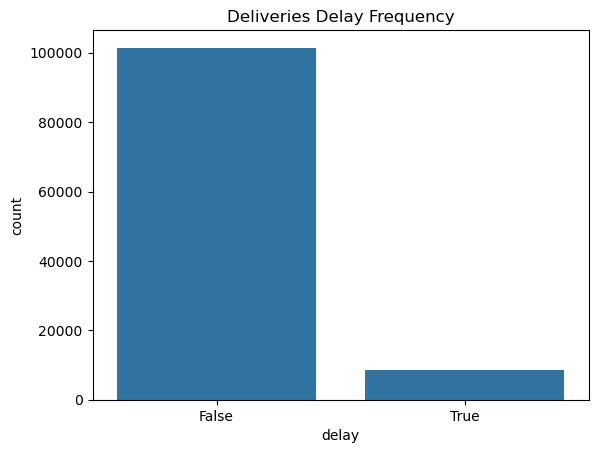

In [28]:
sns.countplot(x="delay", data=df_logistics)
plt.title("Deliveries Delay Frequency")
plt.show()

**Percentage of delays**

The 7.78% of orders represents delays in deliveries. It is a low percentage but the company should analyze the logistics factors to avoid this delays and find out the way to improve this delivery process.

In [29]:
delay_by_state = df_logistics.groupby("customer_state")["delay"].mean().sort_values(ascending=False)
delay_by_state.head(10)

customer_state
AL    0.235981
MA    0.197747
SE    0.158177
PI    0.154143
CE    0.152388
BA    0.134369
RJ    0.128077
TO    0.122977
ES    0.119274
PA    0.113353
Name: delay, dtype: float64

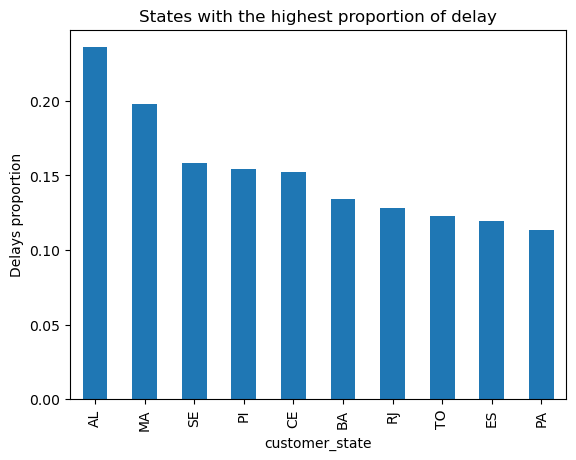

In [30]:
delay_by_state.head(10).plot(kind="bar")
plt.title("States with the highest proportion of delay")
plt.ylabel("Delays proportion")
plt.show()

In [31]:
#Filter states with sufficent volume, has some may have few orders. 
orders_by_state = df_logistics["customer_state"].value_counts()

In [32]:
valid_states = orders_by_state[orders_by_state > 100].index 

In [33]:
df_filtered = df_logistics[df_logistics["customer_state"].isin(valid_states)]

In [34]:
delay_by_state = df_filtered.groupby("customer_state")["delay"].mean().sort_values(ascending=False)

In [35]:
valid_states

Index(['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'DF', 'GO', 'ES', 'PE', 'CE',
       'PA', 'MT', 'MS', 'MA', 'PB', 'RN', 'PI', 'AL', 'SE', 'TO', 'RO', 'AM'],
      dtype='object', name='customer_state')

In [36]:
delay_by_state

customer_state
AL    0.235981
MA    0.197747
SE    0.158177
PI    0.154143
CE    0.152388
BA    0.134369
RJ    0.128077
TO    0.122977
ES    0.119274
PA    0.113353
PB    0.110155
MS    0.108404
RN    0.101923
PE    0.100000
SC    0.094386
GO    0.077365
DF    0.075296
RS    0.068322
MT    0.066084
SP    0.056842
MG    0.053541
PR    0.047273
AM    0.042945
RO    0.040441
Name: delay, dtype: float64

AL was identified as having a 23.59% delay, followed by MA with 19.77%, making it the states with the longest delivery delays. This suggests inefficiences in regional logistics that could be impacting the customer experience.  

In [37]:
df_filtered.groupby("customer_state").agg({
    "delay": "mean",
    "review_score": "mean"}
).sort_values(by="delay", ascending=False)

,delay,review_score
customer_state,,
AL,0.235981,3.815421
MA,0.197747,3.765957
SE,0.158177,3.898123
PI,0.154143,3.961464
CE,0.152388,3.867275
BA,0.134369,3.860725
RJ,0.128077,3.870998
TO,0.122977,4.155340
ES,0.119274,4.017234


**States with a higher rates of delay also have lower average ratings** 

The analysis reveals that delivery delays are not uniform across regions. Some states experience a higher incidence of late deliveries, negatively impacting customer satisfaction. It is recommended that logistic efforts be focused on these regions to improve operational efficency and the user experience.

Sales over time
---

In [38]:
df["total_sale"] = df["price"] + df["freight_value"]

In [39]:
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [40]:
sales_by_month = df.groupby("year_month")["total_sale"].sum()

In [41]:
sales_by_month

year_month
2016-09        354.75
2016-10      56029.40
2016-12         19.62
2017-01     136795.24
2017-02     286239.96
2017-03     427575.12
2017-04     409990.49
2017-05     585016.26
2017-06     503804.55
2017-07     583200.98
2017-08     666063.86
2017-09     718296.87
2017-10     765250.68
2017-11    1176583.91
2017-12     854764.72
2018-01    1101950.27
2018-02     989749.49
2018-03    1147445.42
2018-04    1153692.99
2018-05    1142847.90
2018-06    1020663.90
2018-07    1047531.49
2018-08     998130.36
2018-09        166.46
Freq: M, Name: total_sale, dtype: float64

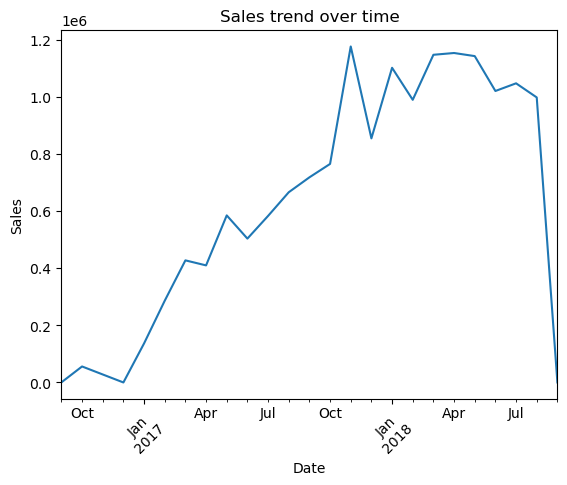

In [42]:
sales_by_month.plot()
plt.title("Sales trend over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

The outliers at the beginning and end of the period correspond to incomplete data, and therefore do not reflect the actual performance of the business.

In [43]:
df_filtered = df[(df["order_purchase_timestamp"] >= "2017-01-01") & 
    (df["order_purchase_timestamp"] <= "2018-08-31")]

In [44]:
df_filtered["year_month"] = df_filtered["order_purchase_timestamp"].dt.to_period("M")

C:\Users\rebec\AppData\Local\Temp\ipykernel_3904\806253567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["year_month"] = df_filtered["order_purchase_timestamp"].dt.to_period("M")


In [45]:
sales_filtered = df_filtered.groupby("year_month")["total_sale"].sum()

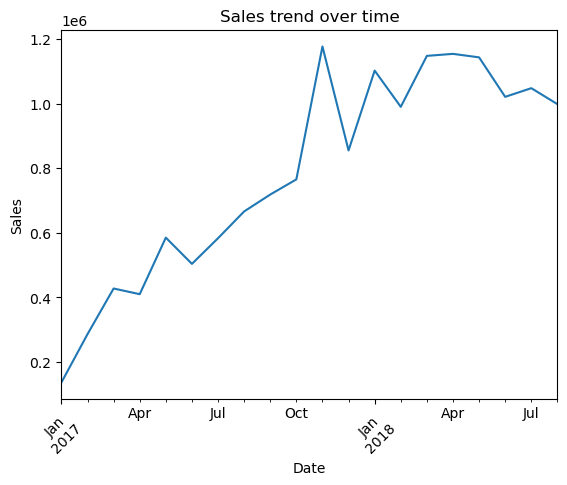

In [46]:
sales_filtered.plot()
plt.title("Sales trend over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

**Stable sales since 2018**

The time-series analysis shows accelerated growth during 2017, followed by stabilization in 2018. A significant peak is identified in November, probably associated with commercial events such as Black Friday.  

Geographic Analysis
---

In [47]:
sales_by_state = df.groupby("customer_state")["total_sale"].sum().sort_values(ascending=False)

In [48]:
sales_by_state

customer_state
SP    5913712.68
RJ    2106383.07
MG    1847692.74
RS     887572.18
PR     801348.70
BA     608037.39
SC     603368.53
DF     354435.96
GO     346702.09
PE     320953.96
ES     312886.37
CE     275044.55
PA     214062.22
MT     185192.76
MA     150615.25
PB     139159.84
MS     137293.30
PI     107255.35
RN     101242.40
AL      94969.16
SE      71883.44
TO      61266.75
RO      57508.97
AM      27650.29
AC      19669.70
AP      16192.42
RR      10064.62
Name: total_sale, dtype: float64

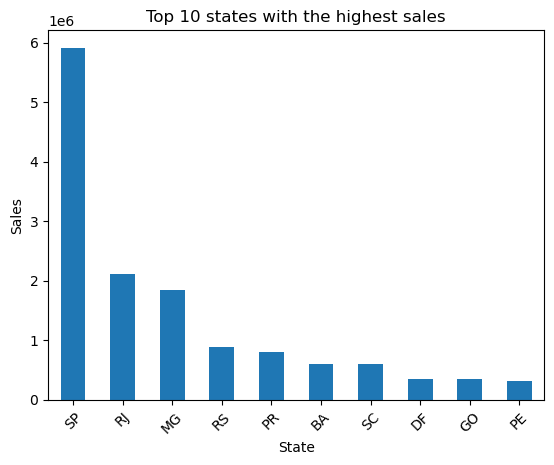

In [49]:
sales_by_state.head(10).plot(kind="bar")
plt.title("Top 10 states with the highest sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

**State with highest sales**

The state SP recorded the highest sales with 5.91M of sales. It suggests sales in this state are characterized by high demand or high-value. The company should analyze the strategies implemented in this state to understand their success and replicate them in other states. 

In [50]:
orders_by_state = df.groupby("customer_state")["order_id"].nunique()

avg_ticket = sales_by_state / orders_by_state

avg_ticket.sort_values(ascending=False)

customer_state
PB    264.562433
AC    242.835802
AP    241.677910
RO    233.776301
AL    232.767549
PA    223.680481
TO    220.383993
PI    219.785553
RR    218.796087
RN    211.804184
SE    208.963488
CE    208.841724
MT    206.688348
MA    204.918707
PE    196.783544
MS    194.191372
AM    190.691655
BA    183.198973
GO    173.872663
SC    168.350594
DF    167.582014
RJ    167.199799
RS    164.000772
PR    161.172305
MG    161.145364
ES    156.599785
SP    143.854452
dtype: float64

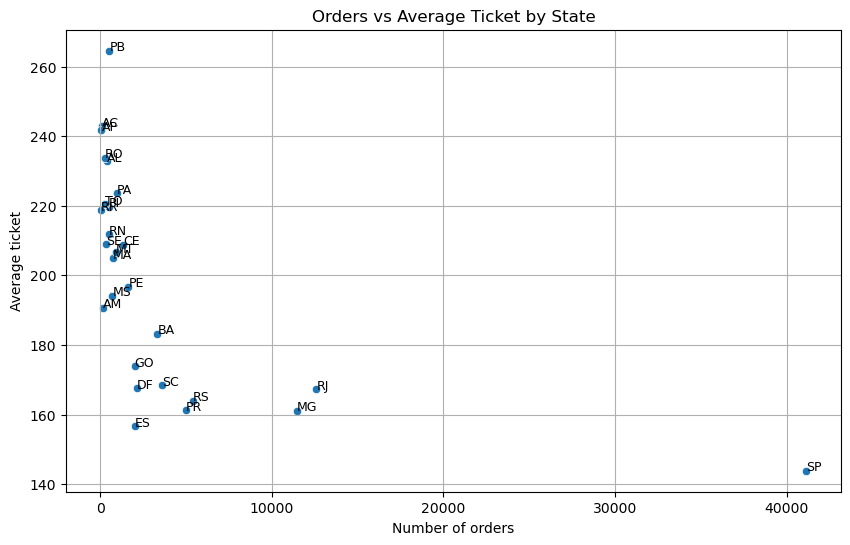

In [52]:
df_plot = pd.DataFrame({
    "orders": orders_by_state,
    "avg_ticket": avg_ticket
})

# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_plot, x="orders", y="avg_ticket")

# Labels in each point (states)
for state, row in df_plot.iterrows():
    plt.text(row["orders"], row["avg_ticket"], state, fontsize=9)

plt.title("Orders vs Average Ticket by State")
plt.xlabel("Number of orders")
plt.ylabel("Average ticket")
plt.grid(True)
plt.show()


**Orders by state**

The state of SP generates the highest revenue (5.91M), driven by a high volume of orders despite having the lowest average ticket size. In contrast, PB records the highest average ticket but with a significantly lower number of orders. This indicates two distinct purchasing behaviors: SP reflects a high-volume, low-value market, whereas PB represents a segment with higher-value transactions but lower purchase frequency. These differences suggest opportunities tailored strategies, such as increasing average ticket size in SP or boosting purchase frequency in PB.

Category Analysis
---

In [53]:
category_translation = pd.read_csv(r"C:\Users\rebec\Documents\REBECA RAYGOZA\data-analysis-portfolio\product_category_name_translation.csv")

In [54]:
df = df.merge(category_translation, on="product_category_name", how="left")

In [55]:
category_sales = df.groupby("product_category_name_english")["total_sale"].sum().sort_values(ascending=False)
category_sales.head(10)

product_category_name_english
health_beauty            1434501.78
watches_gifts            1297404.23
bed_bath_table           1244950.00
sports_leisure           1155295.28
computers_accessories    1062184.42
furniture_decor           902472.18
housewares                775827.36
cool_stuff                712954.07
auto                      678859.45
garden_tools              581483.25
Name: total_sale, dtype: float64

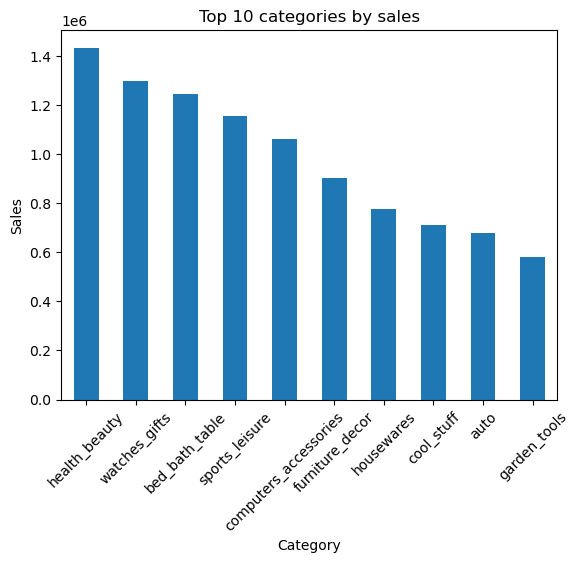

In [56]:
category_sales.head(10).plot(kind="bar")
plt.title("Top 10 categories by sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Health_beauty category has the highest sales with (1.4M). The sales are concentrated in a small number of categories, it suggest the business depends heavily on certain types of products. 

In [57]:
category_orders = df.groupby("product_category_name_english")["order_id"].nunique().sort_values(ascending=False)

In [58]:
category_orders.head(10)

product_category_name_english
bed_bath_table           9313
health_beauty            8771
sports_leisure           7669
computers_accessories    6649
furniture_decor          6398
housewares               5843
watches_gifts            5576
telephony                4168
auto                     3877
toys                     3853
Name: order_id, dtype: int64

In [59]:
category_analysis = df.groupby("product_category_name_english").agg({"total_sale": "sum", "order_id": "nunique"})
category_analysis["avg_ticket"] = category_analysis["total_sale"]/category_analysis["order_id"]
category_analysis.sort_values(by="total_sale", ascending=False).head(10)

,total_sale,order_id,avg_ticket
product_category_name_english,,,
health_beauty,1434501.78,8771,163.550539
watches_gifts,1297404.23,5576,232.676512
bed_bath_table,1244950.00,9313,133.678729
sports_leisure,1155295.28,7669,150.644840
computers_accessories,1062184.42,6649,159.751003
furniture_decor,902472.18,6398,141.055358
housewares,775827.36,5843,132.778942
cool_stuff,712954.07,3599,198.097824
auto,678859.45,3877,175.099162


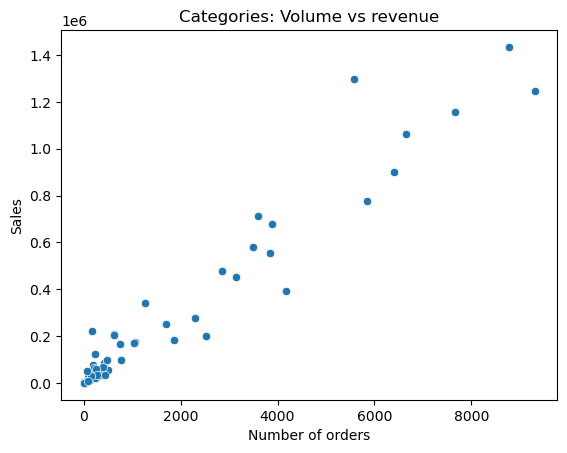

In [60]:
sns.scatterplot(
    data=category_analysis,
    x="order_id",
    y="total_sale"
)

plt.title("Categories: Volume vs revenue")
plt.xlabel("Number of orders")
plt.ylabel("Sales")
plt.show()

**Category with most sales, volume vs revenue**

The healt_beauty category leads in total revenue, driven by a strong and consistent demand. In contrast, watches_gifts stands out with the highest average ticket size, indicating a premium purchasing behavior with higher-value transactions. Meanwhile, bed_bath_table records the highest number of orders, reflecting a high-frequency, lower-value consumption pattern. These findings reveal distinct category dynamics: while some categories generate revenue through high sales volume, others rely on higher transaction values. This segmentation provides opportunities for targeted strategies, such as increasing increase average ticket size in high-volume categories or boosting demand in premium segments.

Key insights:
---
* A significant proportion of orders experience delivery delays, which negatively impacts customer satisfaction.
* Customer satisfaction is strongly influenced by delivery performance.
* Sales show a strong upward trend during 2017, followed by stabilization in 2018. 
* Certain regions outperforms other in sales.
* Some categories generate revenue through high purchase frequency, other through higher transaction value.

Conclusion
---
The analysis reveals that logistics performance is a key driver of customer satisfaction, with delivery delays significantly reducing review scores. Sales growth has been strong, supported by seasonal peaks, while revenue is concentrated in specific regions and categories, highlighting opportunities for targeted strategies.

In [61]:
df.to_csv("final_dataset.csv", index=False)